# Phase 3: Feature Engineering and Model Building
## Transactional Fraud Detection Analysis

This notebook continues from Phase 1 (Data Cleaning) and Phase 2 (EDA).

**Important note carried over from Phase 2:** the dataset has no fraud label column. To build a classification model, we first construct a **rule-based synthetic fraud label** using the suspicious patterns identified during EDA (unusually high transaction amounts, high amount-to-balance ratio, multiple login attempts, and high-value online transactions). This is a standard workaround for unlabeled fraud datasets and is documented clearly so it can be explained to reviewers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', None)

## Step 1: Load Cleaned Data

Loading the dataset produced in Phase 1.

In [2]:
df = pd.read_csv('C:\\INFYNTREK_INTERN_WORK\\cleaned_transactions (1).csv')

df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])

df.shape

(2512, 16)

## Step 2: Feature Engineering

We create new variables as required by the project brief: transaction frequency per account, time gap from the previous recorded activity, and behavioral ratios that can help distinguish suspicious transactions.

**Note on `PreviousTransactionDate`:** in this dataset, this field is consistently *later* than `TransactionDate` for every row (it appears to represent last account activity/login rather than the prior transaction in time order). We take the absolute time difference so the feature still captures the size of the gap rather than producing meaningless negative durations.

In [3]:
# Sort chronologically within each account (good practice even though dates cluster narrowly here)
df = df.sort_values(['AccountID', 'TransactionDate']).reset_index(drop=True)

# Hour of day (kept for completeness, even though Phase 2 found all transactions fall between 4-6 PM)
df['Hour'] = df['TransactionDate'].dt.hour

# Time gap from PreviousTransactionDate (absolute value, in hours)
df['TimeSincePrevTxn_Hours'] = (df['TransactionDate'] - df['PreviousTransactionDate']).abs().dt.total_seconds() / 3600

# Transaction frequency per account (how many transactions this account has in total)
acc_freq = df.groupby('AccountID')['TransactionID'].count().rename('AccountTxnFrequency')
df = df.merge(acc_freq, on='AccountID')

# Amount relative to the customer's account balance - a key fraud signal
# (a transaction that is large relative to typical balance is more suspicious than a large absolute amount alone)
df['AmountToBalanceRatio'] = df['TransactionAmount'] / (df['AccountBalance'] + 1)

# Device & location novelty: accounts that use many different devices/locations may carry more risk
device_count = df.groupby('AccountID')['DeviceID'].nunique().rename('UniqueDevicesPerAccount')
location_count = df.groupby('AccountID')['Location'].nunique().rename('UniqueLocationsPerAccount')
df = df.merge(device_count, on='AccountID').merge(location_count, on='AccountID')

df[['TransactionID','AccountID','Hour','TimeSincePrevTxn_Hours','AccountTxnFrequency',
    'AmountToBalanceRatio','UniqueDevicesPerAccount','UniqueLocationsPerAccount']].head()

,TransactionID,AccountID,Hour,TimeSincePrevTxn_Hours,AccountTxnFrequency,AmountToBalanceRatio,UniqueDevicesPerAccount,UniqueLocationsPerAccount
0,TX001313,AC00001,17,9975.183333,2,0.028947,2,2
1,TX002017,AC00001,16,8535.233333,2,0.050933,2,2
2,TX002121,AC00002,16,15928.166667,7,0.412807,7,7
3,TX000021,AC00002,16,14751.550000,7,0.010313,7,7
4,TX001477,AC00002,16,13167.566667,7,0.001965,7,7


## Step 3: Build a Synthetic Fraud Label

Since there is no ground-truth fraud column, we flag a transaction as suspicious if it matches **at least 2 of the following 4 rules**, each based directly on patterns flagged in Phase 2 EDA:

1. Transaction amount is in the top 5% of all amounts
2. Amount-to-balance ratio is in the top 10% (large relative to the customer's typical balance)
3. Login attempts are 4 or more (possible account takeover attempt)
4. Channel is Online **and** the amount is in the top 15% (high-value online transactions carry more risk than high-value branch/ATM transactions)

Requiring 2+ rules (rather than just 1) keeps the resulting fraud rate realistic — real-world fraud is rare, typically well under 5% of transactions.

In [4]:
amount_95th = df['TransactionAmount'].quantile(0.95)
ratio_90th = df['AmountToBalanceRatio'].quantile(0.90)
amount_85th = df['TransactionAmount'].quantile(0.85)

rule_high_amount = df['TransactionAmount'] > amount_95th
rule_high_ratio = df['AmountToBalanceRatio'] > ratio_90th
rule_high_logins = df['LoginAttempts'] >= 4
rule_online_highvalue = (df['Channel'] == 'Online') & (df['TransactionAmount'] > amount_85th)

rule_score = (rule_high_amount.astype(int) + rule_high_ratio.astype(int) +
              rule_high_logins.astype(int) + rule_online_highvalue.astype(int))

df['IsFraud'] = (rule_score >= 2).astype(int)

print(df['IsFraud'].value_counts())
print(f"Synthetic fraud rate: {df['IsFraud'].mean()*100:.2f}%")

IsFraud
0    2401
1     111
Name: count, dtype: int64
Synthetic fraud rate: 4.42%


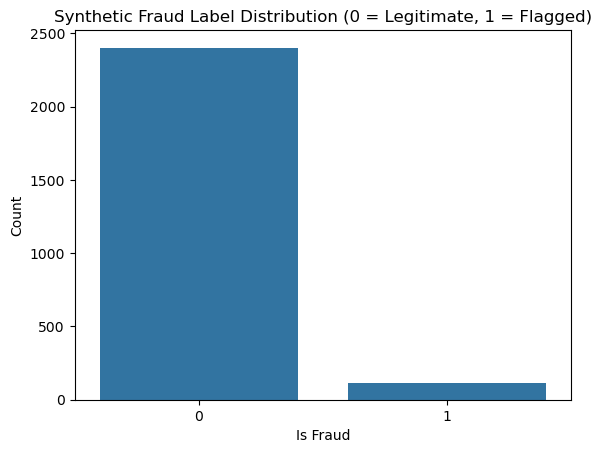

In [5]:
sns.countplot(x='IsFraud', data=df)
plt.title('Synthetic Fraud Label Distribution (0 = Legitimate, 1 = Flagged)')
plt.xlabel('Is Fraud')
plt.ylabel('Count')
plt.show()

## Step 4: Prepare Features for Modeling

We one-hot encode categorical columns and assemble the final feature set. ID-like columns (`TransactionID`, `AccountID`, `DeviceID`, `IP Address`, `MerchantID`, raw dates) are excluded since they don't generalize as predictive features.

In [6]:
cat_cols = ['TransactionType', 'Channel', 'CustomerOccupation']
df_model = pd.get_dummies(df, columns=cat_cols, drop_first=True)

base_features = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts',
                  'AccountBalance', 'Hour', 'TimeSincePrevTxn_Hours', 'AccountTxnFrequency',
                  'AmountToBalanceRatio', 'UniqueDevicesPerAccount', 'UniqueLocationsPerAccount']

encoded_features = [c for c in df_model.columns
                     if c.startswith(('TransactionType_', 'Channel_', 'CustomerOccupation_'))]

feature_cols = base_features + encoded_features

X = df_model[feature_cols]
y = df_model['IsFraud']

print(f"Number of features: {len(feature_cols)}")
feature_cols

Number of features: 17


['TransactionAmount',
 'CustomerAge',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance',
 'Hour',
 'TimeSincePrevTxn_Hours',
 'AccountTxnFrequency',
 'AmountToBalanceRatio',
 'UniqueDevicesPerAccount',
 'UniqueLocationsPerAccount',
 'TransactionType_Debit',
 'Channel_Branch',
 'Channel_Online',
 'CustomerOccupation_Engineer',
 'CustomerOccupation_Retired',
 'CustomerOccupation_Student']

## Step 5: Train/Test Split

We use `stratify=y` to make sure both the training and test sets preserve the same (low) fraud rate — important for imbalanced classification.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train fraud rate: {y_train.mean()*100:.2f}%")
print(f"Test fraud rate:  {y_test.mean()*100:.2f}%")

Train fraud rate: 4.43%
Test fraud rate:  4.37%


## Step 6: Baseline Model — Logistic Regression

We scale features (Logistic Regression is sensitive to feature scale) and use `class_weight='balanced'` to compensate for the class imbalance, instead of resampling techniques like SMOTE (mentioned as a stretch goal in the brief — see note at the end).

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression: Classification Report ===")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")

=== Logistic Regression: Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       481
           1       0.67      1.00      0.80        22

    accuracy                           0.98       503
   macro avg       0.83      0.99      0.89       503
weighted avg       0.99      0.98      0.98       503

ROC-AUC: 0.9980


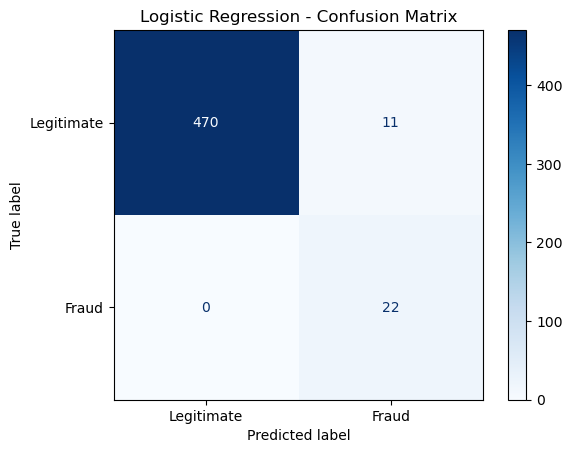

In [9]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['Legitimate','Fraud']).plot(cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

## Step 7: Second Model — Random Forest

Random Forest can capture non-linear patterns and gives us feature importance, which is valuable for explaining *why* a transaction was flagged (important for the "model explainability" point in the project brief).

In [10]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest: Classification Report ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

=== Random Forest: Classification Report ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       481
           1       1.00      0.73      0.84        22

    accuracy                           0.99       503
   macro avg       0.99      0.86      0.92       503
weighted avg       0.99      0.99      0.99       503

ROC-AUC: 1.0000


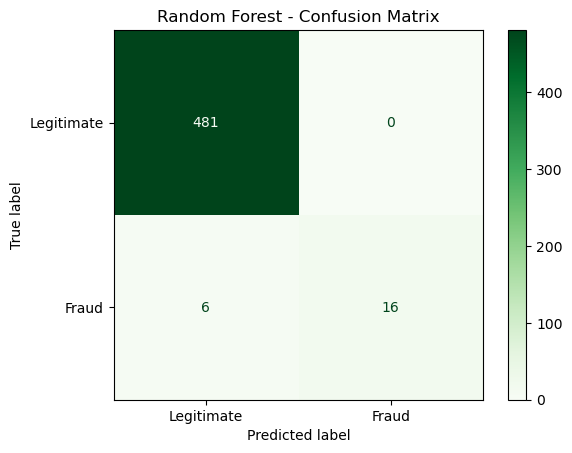

In [11]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Legitimate','Fraud']).plot(cmap='Greens')
plt.title('Random Forest - Confusion Matrix')
plt.show()

## Step 8: ROC Curve Comparison

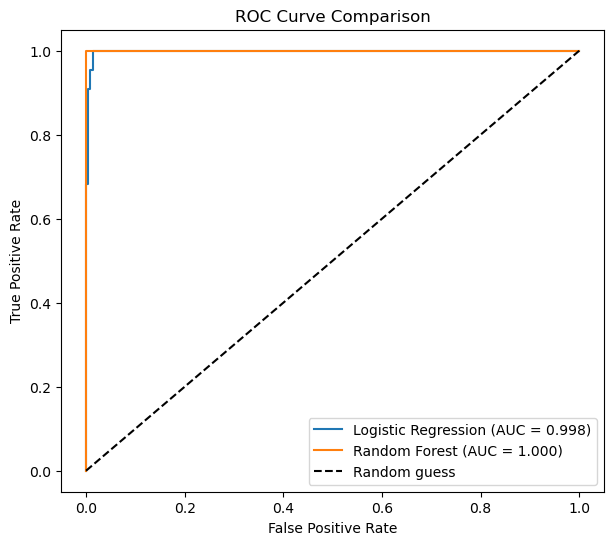

In [12]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(7,6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})')
plt.plot([0,1],[0,1],'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

## Step 9: Feature Importance (Random Forest)

Identifying the top predictors of fraud, as required by the Week 3/Week 4 milestones.

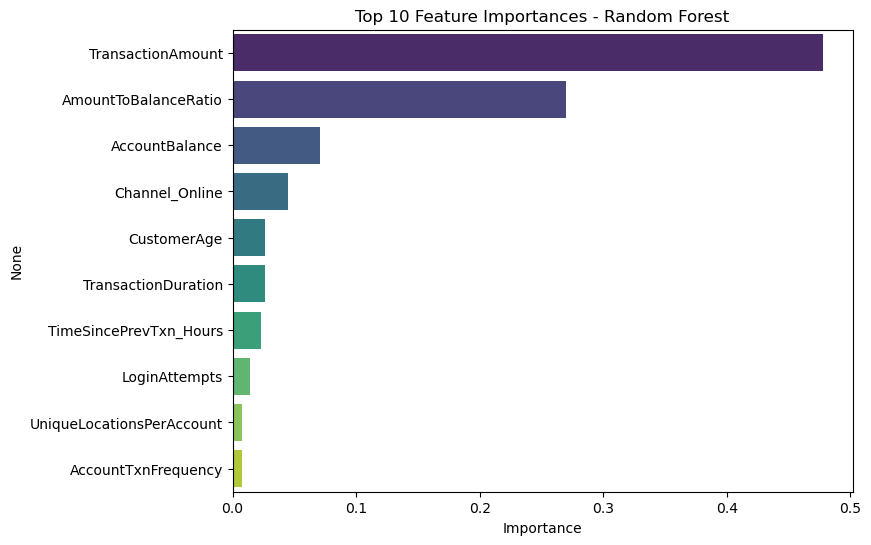

TransactionAmount            0.477797
AmountToBalanceRatio         0.269505
AccountBalance               0.070491
Channel_Online               0.045061
CustomerAge                  0.026161
TransactionDuration          0.026100
TimeSincePrevTxn_Hours       0.022959
LoginAttempts                0.014436
UniqueLocationsPerAccount    0.007908
AccountTxnFrequency          0.007823
dtype: float64

In [13]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.head(10).values, y=importances.head(10).index, hue=importances.head(10).index, palette='viridis', legend=False)
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.show()

importances.head(10)

## Step 10: Save the Model Outputs

Saving the engineered dataset (with the synthetic label and new features) and a results summary, so they're ready for Phase 4 (reporting and dashboard).

In [14]:
df_model.to_csv('C:\\INFYNTREK_INTERN_WORK\\transactions_with_features_and_label.csv', index=False)

results_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC_AUC': [roc_auc_score(y_test, y_proba_lr), roc_auc_score(y_test, y_proba_rf)],
})
results_summary.to_csv('C:\\INFYNTREK_INTERN_WORK\\phase3_model_results.csv', index=False)
results_summary

,Model,ROC_AUC
0,Logistic Regression,0.998015
1,Random Forest,1.000000


## Findings & Limitations (Phase 3)

**What we did:**
- Built a rule-based synthetic fraud label since the dataset had no ground-truth target, using thresholds on transaction amount, amount-to-balance ratio, login attempts, and online channel — all signals flagged during Phase 2 EDA.
- Engineered new features: account transaction frequency, time gap from previous activity, amount-to-balance ratio, and device/location novelty per account.
- Trained and compared two models: Logistic Regression (interpretable baseline) and Random Forest (captures non-linear patterns, gives feature importance).
- Evaluated using Precision, Recall, F1-score, and ROC-AUC rather than plain accuracy, since fraud is a rare class.

**Key limitation to be transparent about:**
Because the fraud label itself was *derived from* transaction amount and the amount-to-balance ratio, it's expected that those same features dominate the model's feature importance and that ROC-AUC scores look very high. This reflects the model successfully learning the rule it was trained on — it does **not** necessarily mean the model would generalize to real, human-labeled fraud cases. In a real-world setting, the label would come from confirmed fraud reports, chargebacks, or investigator decisions rather than rules we define ourselves.

**Possible stretch goals (mentioned in the project brief):**
- Try SMOTE (Synthetic Minority Over-sampling) instead of `class_weight='balanced'` and compare results.
- Try alternative synthetic labeling rules and check how sensitive the model is to those choices.
- Move to Phase 4: build the report and an interactive dashboard (Tableau/Power BI) summarizing these findings for a non-technical audience.